# The Lotka-Volterra model

## Elsie Chilwane (CHLMOT003)
## Introduction to Ocean Modelling
## Marcello Vichi


This model is a python translation of the LV_pz model proposed in Glover et al. (2011), Sec. 9.3

In [ ]:
**DISCLAIMER** : Claude AI was used to complete this assignment. 

In [12]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

This is the function containing the right hand side of the ODE system

In [13]:
def LV_pz(x,t,p):
    X1,X2 = x
    p1,p2,p3,p4 = p
    dX1dt = X1 * (p1 - p2*X2)
    dX2dt = X2 * (p3*p2*X1 - p4)
    return np.array([dX1dt,dX2dt])

## Parameters and initial conditions

In [14]:
# The parameters
p = np.array([0.1,0.4,0.2,0.05])
X1_0 = 0.8
X2_0 = 0.171
x0 = np.array([X1_0,X2_0])

## Time axis

In [15]:
# time units are days
Tstart = 0.
Tend = 400.
step = 0.1
t = np.arange(Tstart,Tend,step)

## Integration using the scipy ODE solver

In [16]:
# note that the extra argument containing the parameter "args" must be a tuple
y = odeint(LV_pz, x0, t, args=(p,))

## Plot Fig. 9.3a

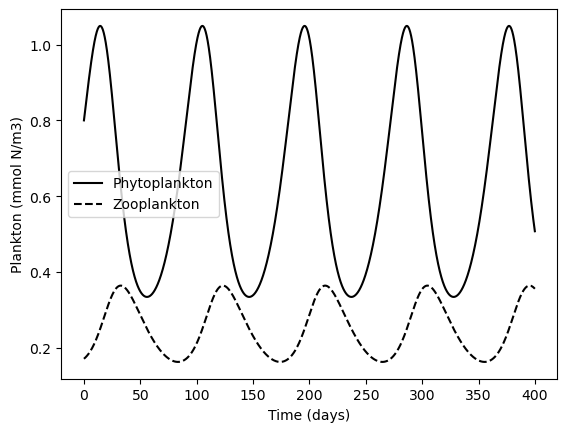

In [17]:
plt.plot(t,y[:,0],'k-',label='Phytoplankton')
plt.plot(t,y[:,1],'k--',label='Zooplankton')
plt.xlabel('Time (days)')
plt.ylabel('Plankton (mmol N/m3)')
plt.legend()
plt.show()

# Exercise 3
1. Write the code to plot Fig. 9.3b, the trajectory in the phase space

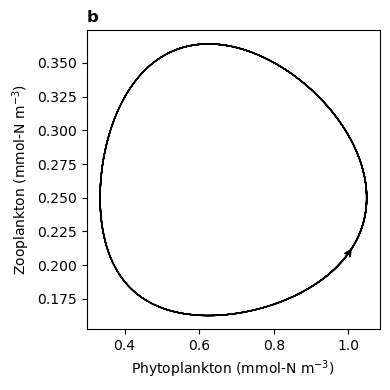

In [22]:

sol = odeint(LV_pz, x0, t, args=(p,), rtol=1e-8, atol=1e-10)
X1, X2 = sol[:, 0], sol[:, 1]

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(X1, X2, color='black', linewidth=1)
mid = len(t) // 4
ax.annotate('', xy=(X1[mid+1], X2[mid+1]), xytext=(X1[mid], X2[mid]),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax.set_xlabel('Phytoplankton (mmol-N m$^{-3}$)')
ax.set_ylabel('Zooplankton (mmol-N m$^{-3}$)')
ax.set_title('b', loc='left', fontweight='bold')
plt.tight_layout(); plt.savefig('PhasePortrait.png', dpi=300); plt.show()

**Figure 1: Time Evolution of phytoplankton (mmol-N m$^{-3}$)) and zooplankton (mmol-N m$^{-3}$) concentrations**

The two populations are linked in a loop. Because, there are lots of phytoplankton, that means lots of food for zooplankton. The zooplankton population grows and the phytoplankton population decreases which causes less food to become available so the zooplankton population starts decreasing which allows the phytoplankton population a window to recover and increase and that causes the cycle. 

2. Set the parameter p3=1 and compare how different the trajectory is in the phase space

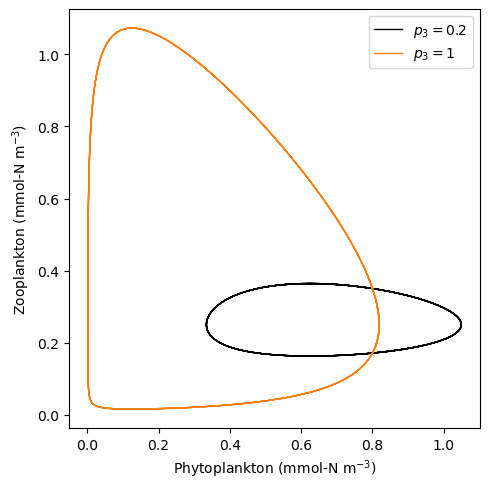

In [20]:
sol_base = odeint(LV_pz, x0, t, args=((0.1, 0.4, 0.2, 0.05),), rtol=1e-8, atol=1e-10)
sol_eff  = odeint(LV_pz, x0, t, args=((0.1, 0.4, 1.0, 0.05),), rtol=1e-8, atol=1e-10)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(sol_base[:, 0], sol_base[:, 1], 'k',          lw=1, label='$p_3 = 0.2$')
ax.plot(sol_eff[:, 0],  sol_eff[:, 1],  'tab:orange', lw=1, label='$p_3 = 1$')
ax.set_xlabel('Phytoplankton (mmol-N m$^{-3}$)')
ax.set_ylabel('Zooplankton (mmol-N m$^{-3}$)')
ax.legend(); plt.tight_layout(); plt.show()

**Figure 2: Phase-space trajectory of the Lotka-Volterra Model** 

Increasing P3 from 0.2 to 1.0 means increasing the efficiency of zooplankton to turn consumed phytoplankton into new zooplankton biomass. This larger P3 value means zooplankton are benefitting biomass-wise from the phyoplankton that they eat. So, the phase-space trajectory changes. 

3. Write the code to compute the solution of the L-V model using the initial conditions given in the caption of Fig. 9.4

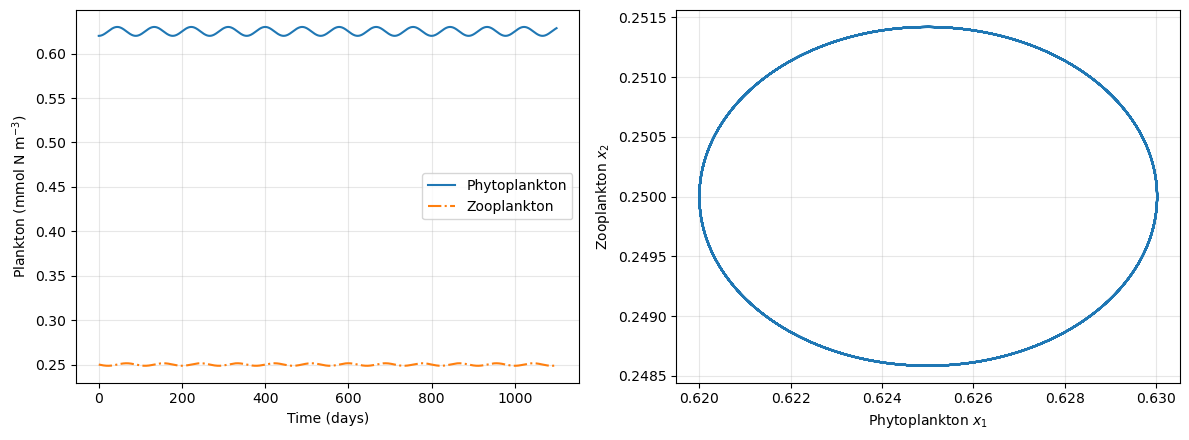

In [24]:
# Q3 — Fig 9.4 initial conditions

T2 = np.arange(0, 1100 + 0.1, 0.1)
sol_b = odeint(LV_pz, [0.62, 0.25], T2, args=((0.1, 0.4, 0.2, 0.05),),
               rtol=1e-8, atol=1e-10)
X1, X2 = sol_b[:, 0], sol_b[:, 1]      # phytoplankton, zooplankton

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(T2, X1, label='Phytoplankton')
ax1.plot(T2, X2, '-.', label='Zooplankton')
ax1.set_xlabel('Time (days)'); ax1.set_ylabel('Plankton (mmol N m$^{-3}$)')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(X1, X2)
ax2.set_xlabel('Phytoplankton $x_1$'); ax2.set_ylabel('Zooplankton $x_2$')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Figure 3: Phase-space trajectory of the Lotka-Volterra Model with initial conditions**

The system still follows a cyclical pattern around a fixed point even with changed intial conditions. 

4. Do you get the same results? Why not? See the errata in the document Glover_etal_2011_ERRATA.pdf to understand more {no need to fully understand the stability analysis ;)}

I don't get the same result as Fig. 9.4 because a numerical solver was used. The solver produces a more stable solution, so the trajectory remains on a closed loop rather than spiralling outward. The Lotka–Volterra system is maintained around a fixed point at (0.625, 0.25) so the phytoplankton-zooplankton cyclical loop is still reproduced. 